In [1]:
import numpy as np
from sklearn.decomposition import PCA

import datasets as hfds
from matplotlib import pyplot as plt
from tqdm import tqdm

from flat_mae.nisc import FC_CMAP, flat_resampler_fslr64k_224_560
from flat_mae.utils import random_seed

In [2]:
hfds.enable_progress_bars()
print(hfds.config.HF_DATASETS_CACHE)
random_seed(42)

/data/connor/huggingface/datasets


In [3]:
url = "s3://medarc/fmri-datasets/eval/hcpya-clips.flat.arrow/train"
dataset = hfds.load_dataset(
    "arrow",
    data_files=f"{url}/*.arrow",
    split="train",
    download_config=hfds.DownloadConfig(num_proc=8),
)

dataset.set_format("numpy")

Resolving data files:   0%|          | 0/126 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/63 [00:00<?, ?it/s]

In [4]:
sample = dataset[0]
print(sample.keys())
print(sample["bold"].shape)
print(len(dataset))

dict_keys(['sub', 'mod', 'task', 'mag', 'dir', 'path', 'start', 'end', 'n_frames', 'tr', 'bold', 'mean', 'std'])
(24, 77763)
8613


In [5]:
X = []
for sample in tqdm(dataset):
    X.append(sample["bold"][:1])
X = np.concatenate(X)
print(X.shape)

100%|██████████| 8613/8613 [00:55<00:00, 154.38it/s]


(8613, 77763)


In [6]:
X_norm = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)
pca = PCA(n_components=8, svd_solver="randomized").fit(X_norm)

In [7]:
resampler = flat_resampler_fslr64k_224_560()
components = np.zeros((8, 224, 560), dtype=np.float32)
sign = np.sign(pca.components_.sum(axis=1, keepdims=True))
components[:, resampler.mask_] = pca.components_ * sign

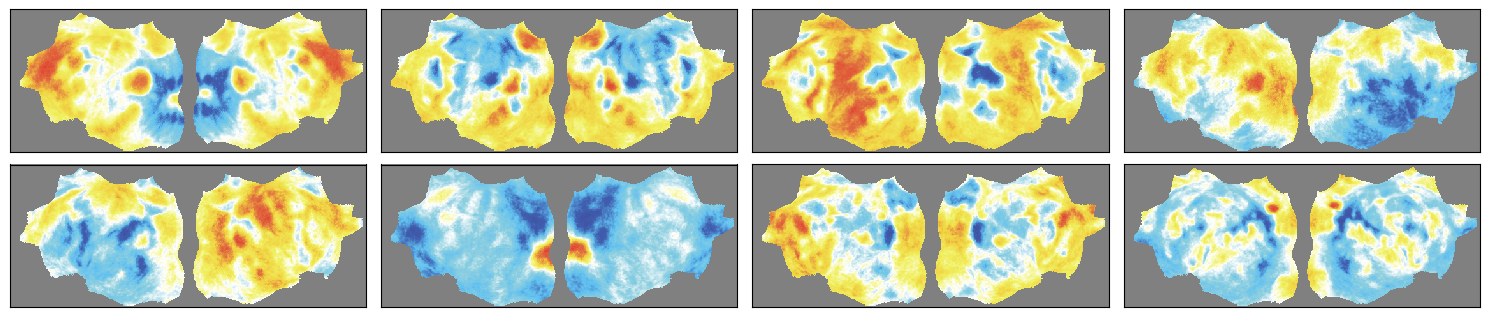

In [8]:
H, W = 224, 560
ploth = 1.5
plotw = (W / H) * ploth

nr = 2
nc = 4
f, axs = plt.subplots(nr, nc, figsize=(nc * plotw, (nr + 0.3) * ploth))
axs = axs.flatten()


for ii, ax in enumerate(axs):
    plt.sca(axs[ii])
    img = components[ii]
    img = np.where(img != 0, img, np.nan)
    plt.imshow(img, cmap=FC_CMAP, interpolation="none")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()

In [9]:
np.savez_compressed("output/flat_pca_n8_224_560.npz", components=components)